In [1]:
import torch 
import torch.fft as fft
import torch.nn as nn
import numpy as np
import h5py
import matplotlib.pyplot as plt

In [2]:
fname = "file1000323.h5"
smaps_fname = "../../datasets/fastmri_preprocessed/knee_coil_combined/pd/val/" + fname
kspace_fname = '../../datasets/fastmri/knee/multicoil_val/' + fname
# slice = 17
with h5py.File(smaps_fname) as f:
    smaps = f['smaps'][()]
    x = f['image'][()]

with h5py.File(kspace_fname) as f:
    kspace = f['kspace'][()]
    volume_kspace = f['kspace'][()]

# Test out mask generation
organ_mask = np.sum(smaps, axis = 0) > 0
x.shape

In [12]:
x.shape

(40, 640, 372)

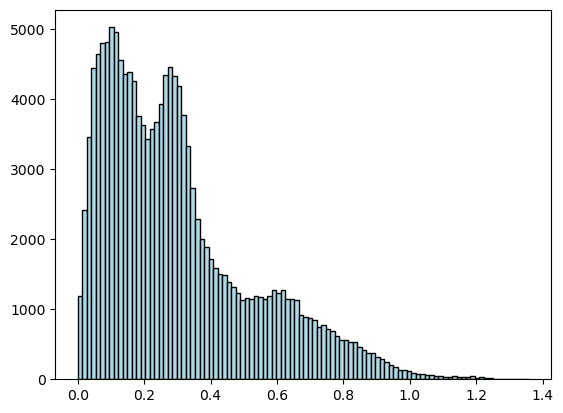

In [9]:
# Make histograms out of coil combined image space
scale_fac = 4e3
# for slice in range(x.shape[1]-1):
for slice in range(21, 22):
    mag_img = np.abs(x[slice, :, :])
    mag_img = mag_img[mag_img > 0].flatten() * scale_fac
    
    plt.hist(mag_img, bins=100, color='lightblue', edgecolor='black')
    plt.show()

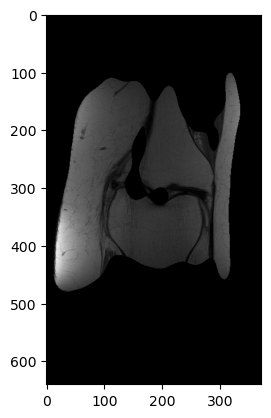

In [5]:
plt.imshow(np.abs(x)*scale_fac, cmap = 'gray')

In [52]:
from mri_utils import mri_awgn, batched_mri_decoding
mask = torch.ones(1, 1, x.shape[-2], x.shape[-1])
x = torch.tensor(x)
smaps = torch.tensor(smaps).view(1, 15, x.shape[-2], x.shape[-1])
kspace_masked_noisy, sigma_n = mri_awgn(x*scale_fac, mask, smaps, [0.01, 0.02])
img_noisy = batched_mri_decoding(kspace_masked_noisy[0], mask, smaps)

/state/partition1/job-4430733/ipykernel_512168/2062867781.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x)
/state/partition1/job-4430733/ipykernel_512168/2062867781.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  smaps = torch.tensor(smaps).view(1, 15, x.shape[-2], x.shape[-1])


In [49]:
(smaps.conj()*ifftc(kspace_masked_noisy[0])).shape

torch.Size([1, 15, 640, 372])

In [47]:
smaps.shape

torch.Size([1, 1, 15, 640, 372])

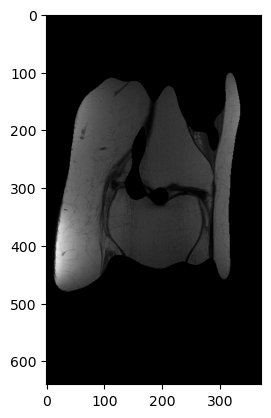

In [53]:
plt.imshow(torch.squeeze(torch.abs(img_noisy)), cmap = 'gray')

In [70]:
# Try computing smaps with different hyperparams
from mri_utils import espirit
kspace = torch.tensor(kspace).to('cuda')
sm = espirit(
    kspace[None],
    acs_size=(24, 24),
    thresh_rowspace=0.01,
    thresh_eig=0.99,
)
# Apply the right flips to sm
sm = torch.flip(sm, dims=(-2, -1))

/state/partition1/job-4430733/ipykernel_512168/3330335686.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  kspace = torch.tensor(kspace).to('cuda')


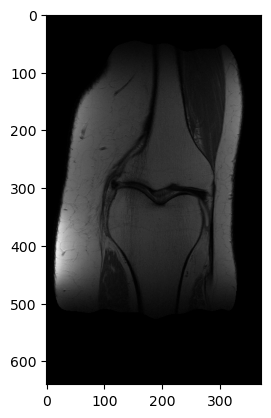

In [72]:
# Perform coil combination with our new smaps
mask = mask.to('cuda')
recon = batched_mri_decoding(kspace, mask, sm)
plt.imshow(recon.abs().detach().cpu().numpy()[0,0], cmap = 'gray')

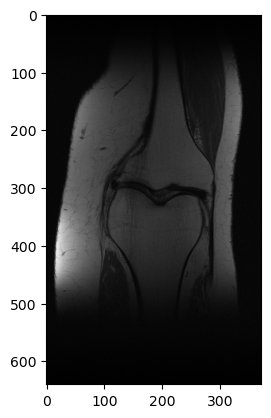

In [83]:
rss = torch.sqrt(torch.sum(ifftc(kspace).abs()**2, dim = 0))
rss.shape
plt.imshow(rss.detach().cpu().numpy(), cmap = 'gray')